<a href="https://colab.research.google.com/github/souptikmaiti/building-llm/blob/main/002_Data_Loader_Input_Output_Pairs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Creating INPUT-OUTPUT Pairs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
verdict_book_path = "/content/drive/MyDrive/building_llms/the-verdict.txt"

In [ ]:
with open(verdict_book_path, "r", encoding="utf-8") as f:
  raw_text = f.read()

print("Total Number of characters:", len(raw_text))
print(raw_text[:99])

Total Number of characters: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [ ]:
! pip install tiktoken

In [ ]:
import importlib
import tiktoken

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [ ]:
enc_sample = enc_text[50:]

In [ ]:
# Context size determines how many tokens are included in the input
context_size = 4

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1] # shift the input array by 1

print(f"x:  {x}")
print(f"y:       {y}")

x:  [290, 4920, 2241, 287]
y:       [4920, 2241, 287, 257]


In [ ]:
# input                   target
# 290                     4920
# 290, 4920               2241
# 290, 4920, 2241         287
# 290, 4920, 2241, 287    257

for i in range(1, context_size+1):
  context = enc_sample[:i]
  desired = enc_sample[i]

  print(context, "-------->", desired)

[290] --------> 4920
[290, 4920] --------> 2241
[290, 4920, 2241] --------> 287
[290, 4920, 2241, 287] --------> 257


each input-output pair -> 1 prediction task

So llm is going through contxt_size number of prediction task in each iteration

In [ ]:
for i in range(1, context_size+1):
  context = enc_sample[:i]
  desired = enc_sample[i]
  print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


There's only one more task before we can turn the tokens into embeddings:implementing an efficient data loader that
iterates over the input dataset and returns the inputs and targets as PyTorch tensors, which
can be thought of as multidimensional arrays.

In particular, we are interested in returning two tensors: an input tensor containing the
text that the LLM sees and a target tensor that includes the targets for the LLM to predict,

## IMPLEMENTING A DATA LOADER

For the efficient data loader implementation, we will use PyTorch's built-in Dataset and
DataLoader classes


Step 1: Tokenize the entire text
    
Step 2: Use a sliding window to chunk the book into overlapping sequences of max_length

Step 3: Return the total number of rows in the dataset

Step 4: Return a single row from the dataset

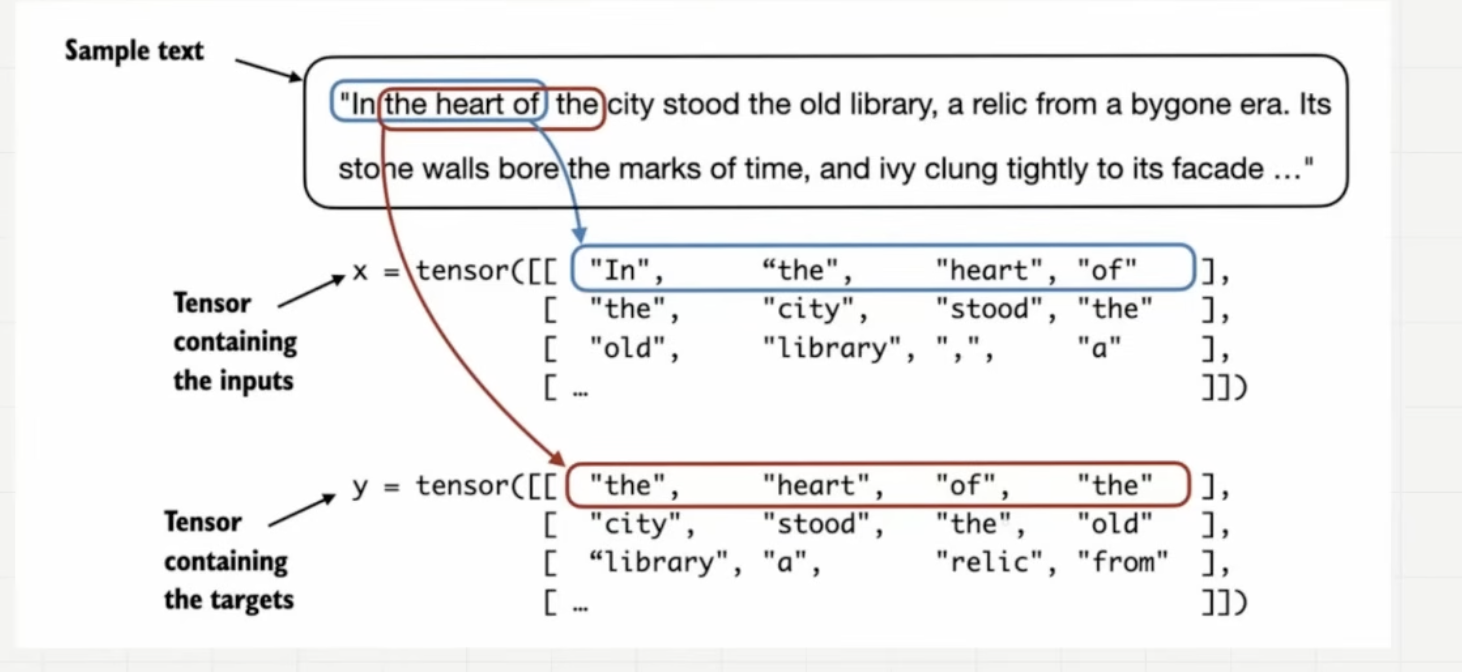

In [ ]:
import torch

In [ ]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
  def __init__(self, txt, tokenizer, max_length, stride):
    # max_length is the context size -> here window size
    # stride is -> by which we slide the window in next iter of for loop
    self.input_ids = []
    self.target_ids = []

    # Tokenize the entire text
    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    # Use sliding window to chunk the book into overlapping seq of max_length
    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i : i + max_length]
      target_chunk = token_ids[i + 1 : i + max_length + 1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]


The GPTDatasetV1 class in listing 2.5 is based on the PyTorch Dataset class.

It defines how individual rows are fetched from the dataset.

Each row consists of a number of
token IDs (based on a max_length) assigned to an input_chunk tensor.

The target_chunk
tensor contains the corresponding targets.

I recommend reading on to see how the data
returned from this dataset looks like when we combine the dataset with a PyTorch
DataLoader -- this will bring additional intuition and clarity.

The following code will use the GPTDatasetV1 to load the inputs in batches via a PyTorch


Step 1: Initialize the tokenizer

Step 2: Create dataset

Step 3: drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes
during training

Step 4: The number of CPU processes to use for preprocessing

In [ ]:
def create_data_loader_v1(txt, batch_size=4, max_length=256,
                          stride=128, shuffle=True, drop_last=True,
                          num_workers=0):
  # batch_size -> no. of batches the model processes at once before updating its parameters
  # num_workers -> parallel proceesing, depends on no. of cpu

  # Intitialize the tokenizer
  tokenizer = tiktoken.get_encoding("gpt2")

  # Create dataset
  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  # Create dataloader
  dataloader = DataLoader(
      dataset=dataset,
      batch_size=batch_size,
      shuffle=shuffle,
      drop_last=drop_last,
      num_workers=num_workers
  )
  return dataloader

Let's test the dataloader with a batch size of 1 for an LLM with a context size of 4,

This will develop an intuition of how the GPTDatasetV1 class and the

Convert dataloader into a Python iterator to fetch the next entry via Python's built-in next() function


In [ ]:
with open(verdict_book_path, "r", encoding="utf-8") as f:
  raw_text = f.read()

In [ ]:
import torch

dataloader = create_data_loader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


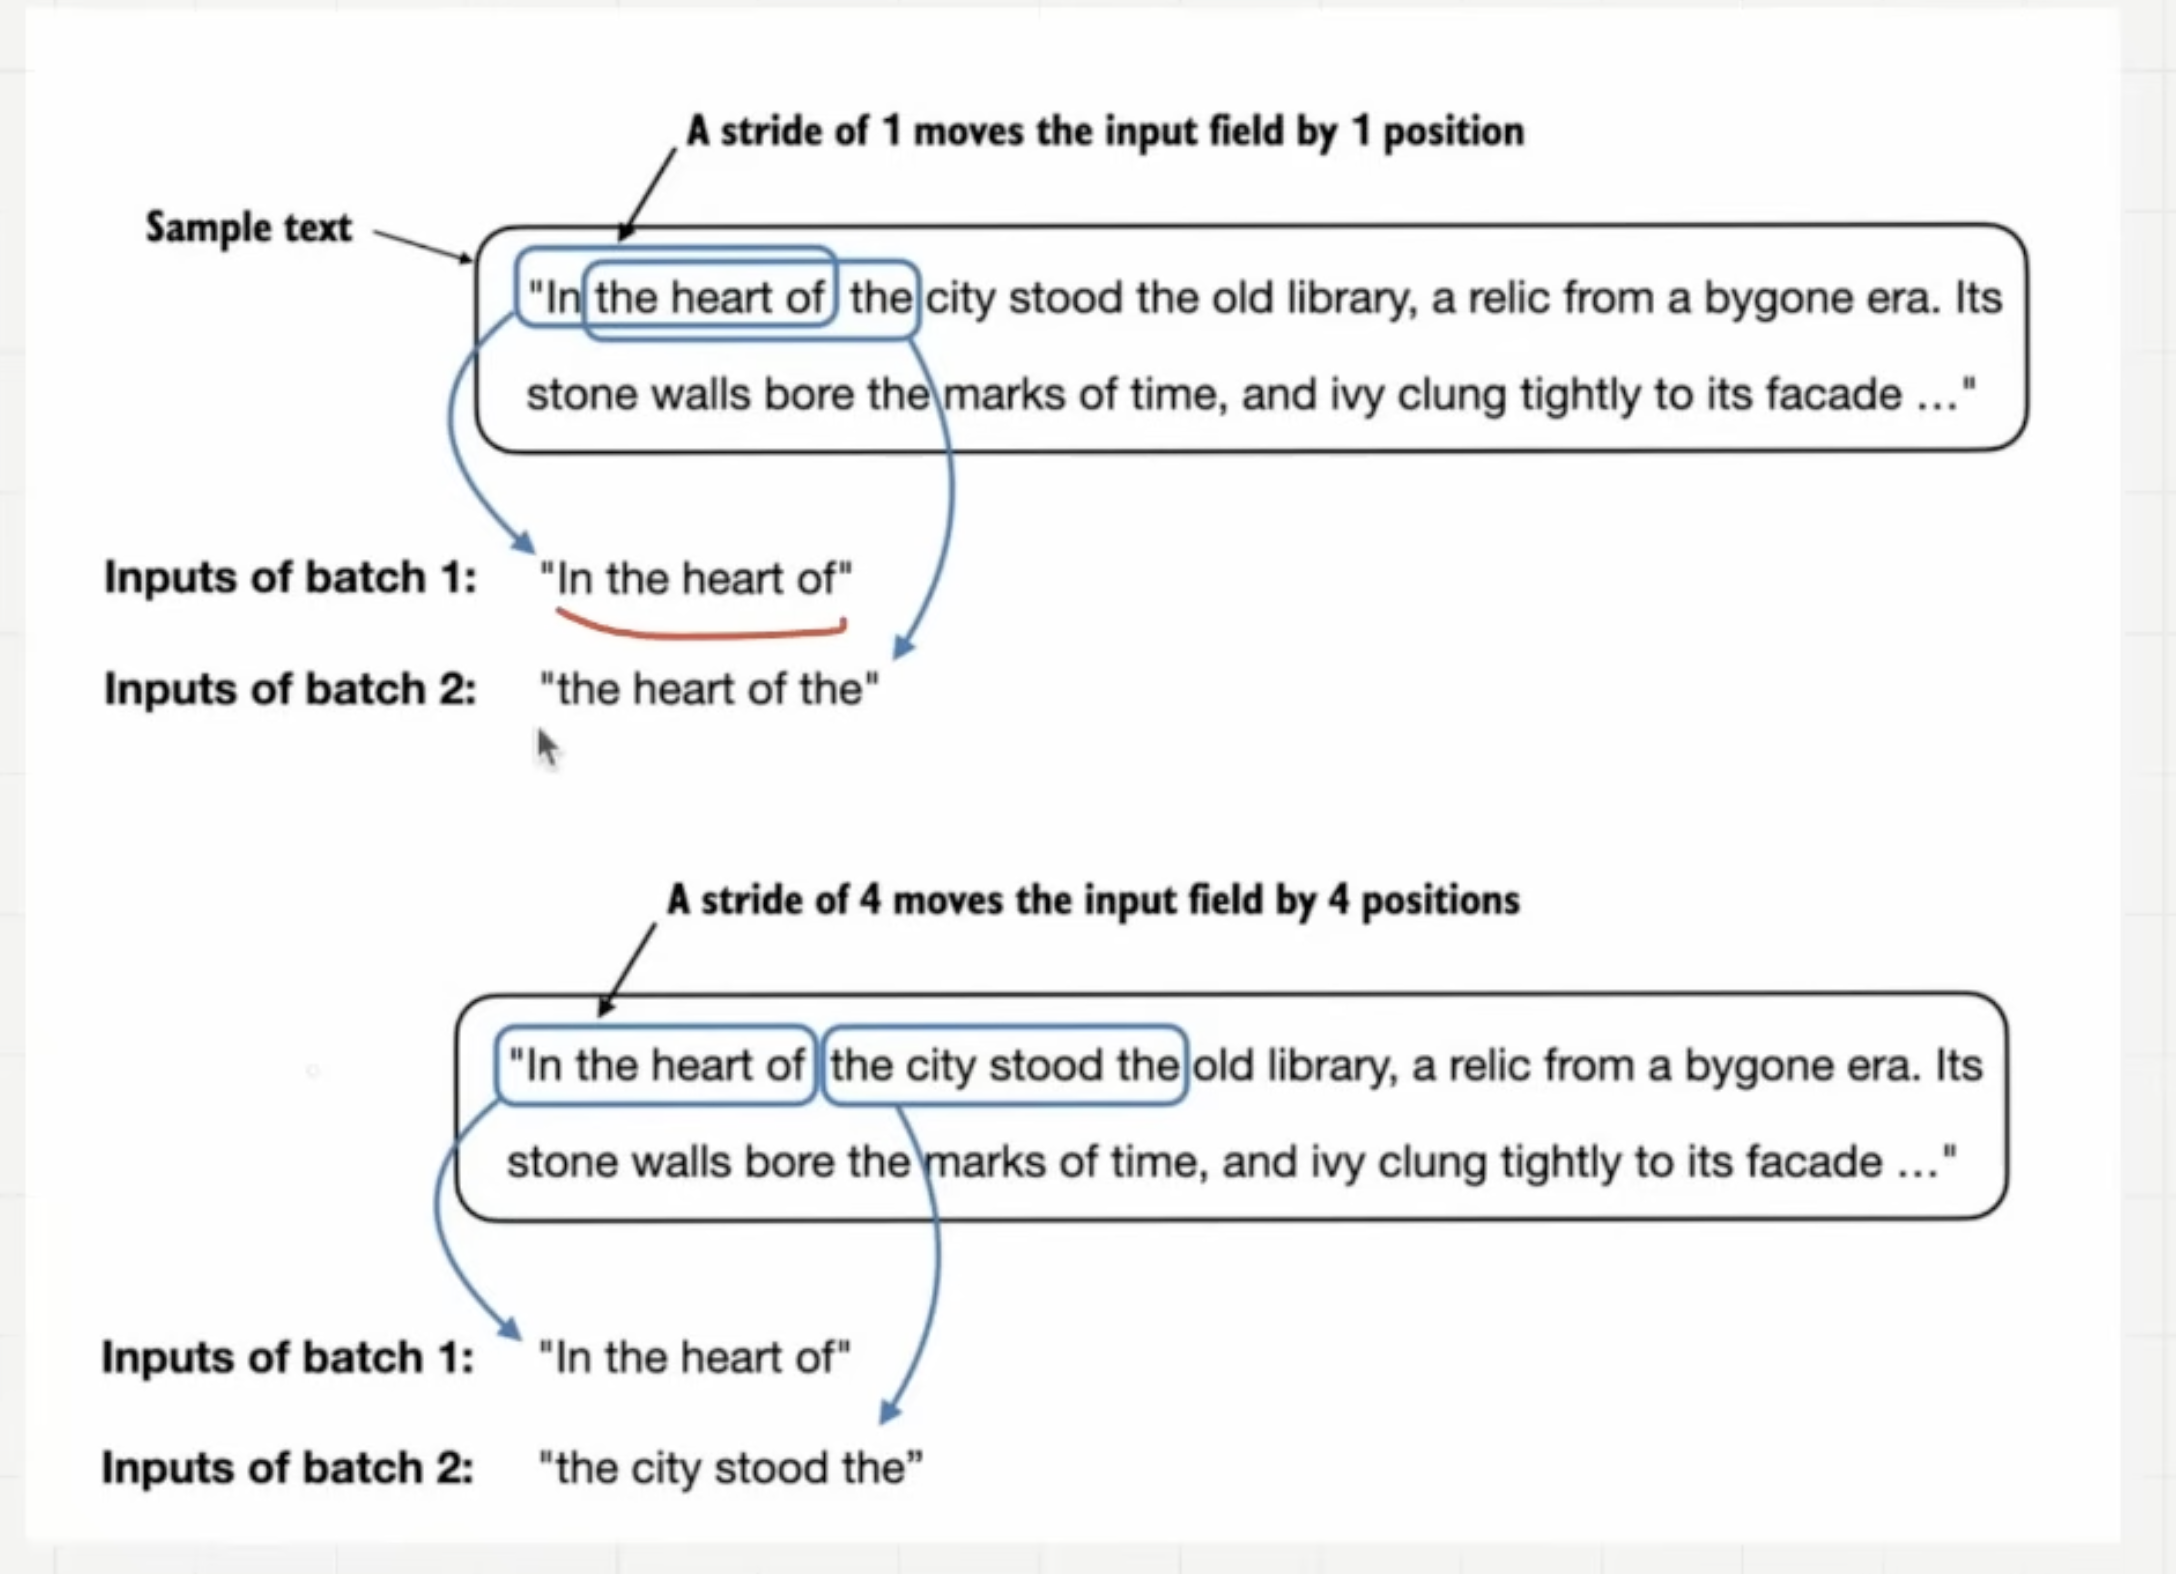

The first_batch variable contains two tensors: the first tensor stores the input token IDs,
and the second tensor stores the target token IDs.

Since the max_length is set to 4, each of the two tensors contains 4 token IDs.

Note that an input size of 4 is relatively small and only chosen for illustration purposes. It is common to train LLMs with input sizes of at least
256.

In [ ]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


If we compare the first with the second batch, we can see that the second batch's token
IDs are shifted by one position compared to the first batch.

For example, the second ID in
the first batch's input is 367, which is the first ID of the second batch's input.

The stride
setting dictates the number of positions the inputs shift across batches, emulating a sliding
window approach

Batch sizes of 1, such as we have sampled from the data loader so far, are useful for
illustration purposes.
                                                                                 
If you have previous experience with deep learning, you may know
that small batch sizes require less memory during training but lead to more noisy model
updates.

Just like in regular deep learning, the batch size is a trade-off and hyperparameter
to experiment with when training LLMs.

In [ ]:
# Now lets make batch size as 8

dataloader = create_data_loader_v1(
    raw_text, batch_size=8, max_length=4, stride=4, shuffle=False
)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)

print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


Note that we increase the stride to 4. This is to utilize the data set fully (we don't skip a
single word) but also avoid any overlap between the batches, since more overlap could lead
to increased overfitting.

In [ ]:
b